# Get Restaurant Info from New York Open Data

In [2]:
import requests
import pandas as pd
import time

BASE_URL = "https://data.cityofnewyork.us/resource/9w7m-hzhe.json"

LIMIT = 50000
OFFSET = 0

all_rows = []

while True:
    params = {
        "$limit": LIMIT,
        "$offset": OFFSET,
        "$select": (
            "camis, dba, boro, building, street, zipcode, "
            "cuisine_description, grade, score, inspection_date, "
            "latitude, longitude"
        ),
        "$where": (
            "boro='Manhattan' "
            "AND latitude IS NOT NULL "
            "AND longitude IS NOT NULL"
        )
    }

    response = requests.get(BASE_URL, params=params)

    if response.status_code != 200:
        print("Error:", response.status_code)
        print(response.text)
        break

    rows = response.json()

    if not rows:
        break

    all_rows.extend(rows)
    print(f"Fetched {len(all_rows)} rows...")

    OFFSET += LIMIT
    time.sleep(0.2)

df = pd.DataFrame(all_rows)

# Convert numeric fields
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df["inspection_date"] = pd.to_datetime(df["inspection_date"], errors="coerce")

# Keep latest inspection record per restaurant
df = df.sort_values("inspection_date", ascending=False)

df_unique = df.drop_duplicates(subset=["camis"], keep="first").copy()

# Rename columns
df_unique = df_unique.rename(columns={
    "camis": "restaurant_id",
    "dba": "name",
    "boro": "borough",
    "cuisine_description": "cuisine",
    "grade": "inspection_grade",
    "score": "inspection_score"
})

# Create full address
df_unique["address"] = (
    df_unique["building"].fillna("") + " " +
    df_unique["street"].fillna("") + ", " +
    df_unique["borough"].fillna("") + ", NY " +
    df_unique["zipcode"].fillna("")
)

# Select useful fields
df_final = df_unique[[
    "restaurant_id",
    "name",
    "borough",
    "address",
    "zipcode",
    "cuisine",
    "inspection_grade",
    "inspection_score",
    "inspection_date",
    "latitude",
    "longitude"
]]

df_final.to_csv("manhattan_restaurants.csv", index=False, encoding="utf-8-sig")

print("Finished.")
print(f"Unique Manhattan restaurants: {len(df_final)}")
print("Saved as manhattan_restaurants.csv")
print(df_final.head())

Fetched 50000 rows...
Fetched 100000 rows...
Fetched 108736 rows...
Finished.
Unique Manhattan restaurants: 12305
Saved as manhattan_restaurants.csv
      restaurant_id                                      name    borough  \
13410      50180332                      HANI'S BAKERY & CAFE  Manhattan   
40803      50137007                   LEO CAFE @ ASIA SOCIETY  Manhattan   
54283      50140956  THE FIFTH AVENUE HOTEL & CAFE CARMELLINI  Manhattan   
42341      50100305                                 ERNESTO'S  Manhattan   
78406      50144506                                      NAKS  Manhattan   

                                      address zipcode             cuisine  \
13410   67 COOPER SQUARE, Manhattan, NY 10003   10003               Other   
40803    725 PARK AVENUE, Manhattan, NY 10021   10021  Asian/Asian Fusion   
54283       250 5 AVENUE, Manhattan, NY 10001   10001            American   
42341  259 EAST BROADWAY, Manhattan, NY 10002   10002             Spanish   
78406    

# Get Pedestrain Data from New York Open Data

In [4]:
import requests
import pandas as pd

# =========================
# 1. Pedestrian Counts
# =========================

PED_URL = "https://data.cityofnewyork.us/resource/cqsj-cfgu.json"

params = {
    "$limit": 50000,
    "$where": "the_geom IS NOT NULL"
}

ped_response = requests.get(PED_URL, params=params)
print("Pedestrian status:", ped_response.status_code)

ped_data = ped_response.json()
ped_df = pd.DataFrame(ped_data)

print("Pedestrian columns:")
print(ped_df.columns)

ped_df.to_csv("manhattan_pedestrian_counts_raw.csv", index=False, encoding="utf-8-sig")

print("Saved: manhattan_pedestrian_counts_raw.csv")
print("Rows:", len(ped_df))

Pedestrian status: 200
Pedestrian columns:
Index(['the_geom', 'objectid', 'loc', 'borough', 'street_nam', 'from_stree',
       'to_street', 'iex', 'may_07_am', 'may_07_pm',
       ...
       'oct24_md', 'may25_am', 'may25_pm', 'may25_md', 'oct25_am', 'oct25_pm',
       'oct25_md', 'may_19_am', 'may_19_pm', 'may_19_md'],
      dtype='object', length=116)
Saved: manhattan_pedestrian_counts_raw.csv
Rows: 114


# Get Taxi Data from New York Open Data

In [6]:
import pandas as pd

# =========================
# 1. Download Taxi Zone Lookup
# =========================

lookup_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

zone_lookup = pd.read_csv(lookup_url)

manhattan_zones = zone_lookup[
    zone_lookup["Borough"] == "Manhattan"
]["LocationID"].tolist()

print(f"Manhattan taxi zones: {len(manhattan_zones)}")


# =========================
# 2. Aggregate Yellow Taxi Dropoffs by Month
# =========================

all_monthly_results = []

YEAR = 2025

for month in range(1, 13):
    taxi_url = (
        f"https://d37ci6vzurychx.cloudfront.net/trip-data/"
        f"yellow_tripdata_{YEAR}-{month:02d}.parquet"
    )

    print(f"\nLoading: {taxi_url}")

    try:
        taxi_df = pd.read_parquet(
            taxi_url,
            columns=[
                "tpep_dropoff_datetime",
                "DOLocationID",
                "passenger_count",
                "trip_distance"
            ]
        )
    except Exception as e:
        print(f"Failed to load month {month}: {e}")
        continue

    print(f"Rows before filtering: {len(taxi_df):,}")

    # Convert datetime
    taxi_df["tpep_dropoff_datetime"] = pd.to_datetime(
        taxi_df["tpep_dropoff_datetime"],
        errors="coerce"
    )

    # Remove invalid rows
    taxi_df = taxi_df.dropna(subset=["tpep_dropoff_datetime", "DOLocationID"])

    # Keep only Manhattan dropoff zones
    taxi_df = taxi_df[
        taxi_df["DOLocationID"].isin(manhattan_zones)
    ].copy()

    print(f"Rows after Manhattan filtering: {len(taxi_df):,}")

    if taxi_df.empty:
        continue

    # Create time features
    taxi_df["month"] = taxi_df["tpep_dropoff_datetime"].dt.month
    taxi_df["weekday"] = taxi_df["tpep_dropoff_datetime"].dt.dayofweek
    taxi_df["hour"] = taxi_df["tpep_dropoff_datetime"].dt.hour

    # Optional cleaning
    taxi_df = taxi_df[
        (taxi_df["trip_distance"] >= 0) &
        (taxi_df["passenger_count"].fillna(1) >= 0)
    ]

    # Aggregate
    monthly_agg = (
        taxi_df
        .groupby(
            [
                "DOLocationID",
                "month",
                "weekday",
                "hour"
            ]
        )
        .agg(
            dropoff_count=("DOLocationID", "size"),
            passenger_count_sum=("passenger_count", "sum"),
            avg_trip_distance=("trip_distance", "mean")
        )
        .reset_index()
    )

    all_monthly_results.append(monthly_agg)

    print(f"Aggregated rows: {len(monthly_agg):,}")


# =========================
# 3. Combine All Months
# =========================

if not all_monthly_results:
    raise ValueError("No taxi data was collected. Please check URLs or network connection.")

demand_df = pd.concat(all_monthly_results, ignore_index=True)


# =========================
# 4. Add Taxi Zone Name
# =========================

demand_df = demand_df.merge(
    zone_lookup[["LocationID", "Borough", "Zone", "service_zone"]],
    left_on="DOLocationID",
    right_on="LocationID",
    how="left"
)

demand_df = demand_df.rename(columns={
    "DOLocationID": "taxi_zone_id",
    "Zone": "taxi_zone_name",
    "Borough": "borough"
})

demand_df = demand_df[
    [
        "taxi_zone_id",
        "taxi_zone_name",
        "borough",
        "service_zone",
        "month",
        "weekday",
        "hour",
        "dropoff_count",
        "passenger_count_sum",
        "avg_trip_distance"
    ]
]


# =========================
# 5. Export
# =========================

output_file = "manhattan_hourly_demand.csv"

demand_df.to_csv(output_file, index=False, encoding="utf-8-sig")

print("\nFinished.")
print(f"Saved as: {output_file}")
print(f"Total aggregated rows: {len(demand_df):,}")
print(demand_df.head())

Manhattan taxi zones: 69

Loading: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-01.parquet
Rows before filtering: 3,475,226
Rows after Manhattan filtering: 3,116,979
Aggregated rows: 10,886

Loading: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-02.parquet
Rows before filtering: 3,577,543
Rows after Manhattan filtering: 3,190,416
Aggregated rows: 10,918

Loading: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-03.parquet
Rows before filtering: 4,145,257
Rows after Manhattan filtering: 3,620,516
Aggregated rows: 10,988

Loading: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-04.parquet
Rows before filtering: 3,970,553
Rows after Manhattan filtering: 3,476,187
Aggregated rows: 10,986

Loading: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-05.parquet
Rows before filtering: 4,591,845
Rows after Manhattan filtering: 3,952,013
Aggregated rows: 11,056

Loading: https://d37ci6vzuryc

# Data Cleaning for Restauraunt

In [8]:
import pandas as pd
import numpy as np

# =========================
# 1. Load raw restaurant data
# =========================

input_file = "manhattan_restaurants.csv"
output_file = "restaurant_clean.csv"

df = pd.read_csv(input_file)

print("Raw shape:", df.shape)
print("Raw columns:", df.columns.tolist())


# =========================
# 2. Standardize column names
# =========================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Standardized columns:", df.columns.tolist())


# =========================
# 3. Convert numeric columns
# =========================

numeric_cols = ["latitude", "longitude", "inspection_score"]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# =========================
# 4. Convert date columns
# =========================

if "inspection_date" in df.columns:
    df["inspection_date"] = pd.to_datetime(
        df["inspection_date"],
        errors="coerce"
    )


# =========================
# 5. Drop rows with missing key fields
# =========================

required_cols = [
    "restaurant_id",
    "name",
    "cuisine",
    "latitude",
    "longitude"
]

missing_required = [
    col for col in required_cols
    if col not in df.columns
]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df = df.dropna(subset=required_cols)

print("After dropping missing key fields:", df.shape)


# =========================
# 6. Clean text fields
# =========================

df["restaurant_id"] = df["restaurant_id"].astype(str).str.strip()

df["name"] = (
    df["name"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df["cuisine"] = (
    df["cuisine"]
    .astype(str)
    .str.strip()
    .str.title()
)

if "address" in df.columns:
    df["address"] = (
        df["address"]
        .astype(str)
        .str.strip()
        .str.upper()
    )
else:
    df["address"] = np.nan

if "zipcode" in df.columns:
    df["zipcode"] = (
        df["zipcode"]
        .astype(str)
        .str.replace(".0", "", regex=False)
        .str.strip()
    )
else:
    df["zipcode"] = np.nan


# =========================
# 7. Remove invalid restaurant names
# =========================

bad_names = [
    "",
    "NAN",
    "UNKNOWN",
    "NOT LISTED",
    "TEST",
    "N/A",
    "NA",
    "NONE"
]

df = df[~df["name"].isin(bad_names)]

print("After removing bad names:", df.shape)


# =========================
# 8. Filter Manhattan coordinate range
# =========================

df = df[
    (df["latitude"] >= 40.7000) &
    (df["latitude"] <= 40.8800) &
    (df["longitude"] >= -74.0300) &
    (df["longitude"] <= -73.9000)
].copy()

print("After Manhattan coordinate filtering:", df.shape)


# =========================
# 9. Keep latest inspection if duplicates exist
# =========================

if "inspection_date" in df.columns:
    df = df.sort_values("inspection_date", ascending=False)

df = df.drop_duplicates(
    subset=["restaurant_id"],
    keep="first"
).copy()

print("After restaurant_id deduplication:", df.shape)


# =========================
# 10. Optional: remove duplicate same name + same address
# =========================

if "address" in df.columns:
    df = df.drop_duplicates(
        subset=["name", "address"],
        keep="first"
    ).copy()

print("After name + address deduplication:", df.shape)


# =========================
# 11. Standardize inspection fields
# =========================

if "inspection_grade" not in df.columns:
    df["inspection_grade"] = np.nan

if "inspection_score" not in df.columns:
    df["inspection_score"] = np.nan

df["inspection_grade"] = (
    df["inspection_grade"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({"NAN": np.nan})
)


# =========================
# 12. Keep useful columns
# =========================

final_cols = [
    "restaurant_id",
    "name",
    "cuisine",
    "address",
    "zipcode",
    "inspection_grade",
    "inspection_score",
    "inspection_date",
    "latitude",
    "longitude"
]

for col in final_cols:
    if col not in df.columns:
        df[col] = np.nan

restaurant_clean = df[final_cols].copy()

restaurant_clean = restaurant_clean.rename(columns={
    "latitude": "lat",
    "longitude": "lon"
})


# =========================
# 13. Export
# =========================

restaurant_clean.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print("\nFinished.")
print(f"Saved as: {output_file}")
print("Clean shape:", restaurant_clean.shape)
print("Unique restaurants:", restaurant_clean["restaurant_id"].nunique())
print("Unique cuisines:", restaurant_clean["cuisine"].nunique())

print("\nTop 20 cuisines:")
print(restaurant_clean["cuisine"].value_counts().head(20))

print("\nPreview:")
print(restaurant_clean.head())

Raw shape: (12305, 11)
Raw columns: ['restaurant_id', 'name', 'borough', 'address', 'zipcode', 'cuisine', 'inspection_grade', 'inspection_score', 'inspection_date', 'latitude', 'longitude']
Standardized columns: ['restaurant_id', 'name', 'borough', 'address', 'zipcode', 'cuisine', 'inspection_grade', 'inspection_score', 'inspection_date', 'latitude', 'longitude']
After dropping missing key fields: (10750, 11)
After removing bad names: (10750, 11)
After Manhattan coordinate filtering: (10567, 11)
After restaurant_id deduplication: (10567, 11)
After name + address deduplication: (10504, 11)

Finished.
Saved as: restaurant_clean.csv
Clean shape: (10504, 10)
Unique restaurants: 10504
Unique cuisines: 88

Top 20 cuisines:
cuisine
American                          2375
Coffee/Tea                        1094
Italian                            591
Japanese                           553
Chinese                            527
Pizza                              471
Bakery Products/Desserts       

In [9]:
restaurant_clean["cuisine"].value_counts().head(31)

cuisine
American                          2375
Coffee/Tea                        1094
Italian                            591
Japanese                           553
Chinese                            527
Pizza                              471
Bakery Products/Desserts           307
Mexican                            291
Other                              232
French                             228
Juice, Smoothies, Fruit Salads     202
Latin American                     199
Sandwiches                         195
Asian/Asian Fusion                 192
Korean                             177
Mediterranean                      171
Donuts                             163
Indian                             147
Thai                               146
Chicken                            146
Frozen Desserts                    141
Hamburgers                         140
Tex-Mex                            116
New American                       115
Spanish                            113
Irish            

In [10]:
restaurant_clean.shape

(10504, 10)

In [11]:
restaurant_clean["address"].head()

0           67 COOPER SQUARE, MANHATTAN, NY 10003
2               250 5 AVENUE, MANHATTAN, NY 10001
3          259 EAST BROADWAY, MANHATTAN, NY 10002
4               201 1 AVENUE, MANHATTAN, NY 10003
5    205 EAST HOUSTON STREET, MANHATTAN, NY 10002
Name: address, dtype: object

# Get the Building Area

In [13]:
import requests
import pandas as pd
import time

# NYC Open Data PLUTO Socrata endpoint
BASE_URL = "https://data.cityofnewyork.us/resource/64uk-42ks.json"

OUTPUT_FILE = "manhattan_pluto.csv"

LIMIT = 50000
OFFSET = 0

all_rows = []

# Manhattan borough code in PLUTO is usually MN
where_clause = (
    "borough = 'MN' "
    "AND latitude IS NOT NULL "
    "AND longitude IS NOT NULL"
)

select_cols = (
    "borough, block, lot, bbl, address, zipcode, "
    "latitude, longitude, "
    "landuse, lotarea, bldgarea, comarea, retailarea, officearea, "
    "resarea, numfloors, unitsres, unitstotal, yearbuilt"
)

while True:
    params = {
        "$limit": LIMIT,
        "$offset": OFFSET,
        "$select": select_cols,
        "$where": where_clause
    }

    response = requests.get(BASE_URL, params=params)

    if response.status_code != 200:
        print("Error:", response.status_code)
        print(response.text)
        break

    rows = response.json()

    if not rows:
        break

    all_rows.extend(rows)
    print(f"Fetched {len(all_rows):,} PLUTO rows...")

    OFFSET += LIMIT
    time.sleep(0.2)

pluto = pd.DataFrame(all_rows)

print("Raw PLUTO shape:", pluto.shape)
print("Columns:", pluto.columns.tolist())

# Convert numeric columns
numeric_cols = [
    "block", "lot", "bbl", "zipcode",
    "latitude", "longitude",
    "landuse", "lotarea", "bldgarea", "comarea", "retailarea",
    "officearea", "resarea", "numfloors", "unitsres",
    "unitstotal", "yearbuilt"
]

for col in numeric_cols:
    if col in pluto.columns:
        pluto[col] = pd.to_numeric(pluto[col], errors="coerce")

# Clean address
if "address" in pluto.columns:
    pluto["address"] = (
        pluto["address"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

# Keep Manhattan coordinate range
pluto = pluto[
    (pluto["latitude"] >= 40.7000) &
    (pluto["latitude"] <= 40.8800) &
    (pluto["longitude"] >= -74.0300) &
    (pluto["longitude"] <= -73.9000)
].copy()

# Remove invalid area records
pluto = pluto[
    (pluto["bldgarea"].fillna(0) >= 0) &
    (pluto["lotarea"].fillna(0) >= 0)
].copy()

# Useful derived fields
pluto["commercial_area_proxy"] = pluto[["comarea", "retailarea"]].max(axis=1)

pluto["has_commercial_space"] = (
    pluto["commercial_area_proxy"].fillna(0) > 0
).astype(int)

pluto.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")

print("\nFinished.")
print(f"Saved as: {OUTPUT_FILE}")
print("Clean PLUTO shape:", pluto.shape)

print("\nArea summary:")
print(
    pluto[
        ["lotarea", "bldgarea", "comarea", "retailarea", "commercial_area_proxy"]
    ].describe()
)

print("\nPreview:")
print(pluto.head())

Fetched 42,102 PLUTO rows...
Raw PLUTO shape: (42102, 19)
Columns: ['borough', 'block', 'lot', 'bbl', 'address', 'zipcode', 'latitude', 'longitude', 'landuse', 'lotarea', 'bldgarea', 'comarea', 'retailarea', 'officearea', 'resarea', 'numfloors', 'unitsres', 'unitstotal', 'yearbuilt']

Finished.
Saved as: manhattan_pluto.csv
Clean PLUTO shape: (42095, 21)

Area summary:
            lotarea      bldgarea       comarea    retailarea  \
count  4.206000e+04  4.205700e+04  3.967100e+04  3.967100e+04   
mean   1.175103e+04  4.327915e+04  2.032794e+04  2.695625e+03   
std    2.371677e+05  1.642616e+05  1.405561e+05  2.173873e+04   
min    1.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    1.939000e+03  4.525000e+03  0.000000e+00  0.000000e+00   
50%    2.523000e+03  9.135000e+03  1.000000e+03  0.000000e+00   
75%    6.025000e+03  2.460000e+04  4.342500e+03  1.900000e+03   
max    3.659000e+07  1.343508e+07  1.343508e+07  2.192088e+06   

       commercial_area_proxy  
count      

# Get Restauraunt Area

In [15]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree

# =========================
# 1. Load data
# =========================

restaurant_file = "restaurant_clean.csv"
pluto_file = "manhattan_pluto.csv"
output_file = "restaurant_area.csv"

restaurants = pd.read_csv(restaurant_file)
pluto = pd.read_csv(pluto_file)

print("Restaurants:", restaurants.shape)
print("PLUTO:", pluto.shape)


# =========================
# 2. Standardize column names
# =========================

restaurants.columns = (
    restaurants.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

pluto.columns = (
    pluto.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)


# =========================
# 3. Convert numeric fields
# =========================

for col in ["lat", "lon"]:
    restaurants[col] = pd.to_numeric(restaurants[col], errors="coerce")

pluto_numeric_cols = [
    "bbl", "latitude", "longitude",
    "lotarea", "bldgarea", "comarea", "retailarea",
    "officearea", "resarea", "numfloors", "unitstotal"
]

for col in pluto_numeric_cols:
    if col in pluto.columns:
        pluto[col] = pd.to_numeric(pluto[col], errors="coerce")


# =========================
# 4. Basic cleaning
# =========================

restaurants = restaurants.dropna(
    subset=["restaurant_id", "name", "cuisine", "lat", "lon"]
).copy()

pluto = pluto.dropna(
    subset=["bbl", "latitude", "longitude"]
).copy()

# Manhattan coordinate range
restaurants = restaurants[
    (restaurants["lat"] >= 40.7000) &
    (restaurants["lat"] <= 40.8800) &
    (restaurants["lon"] >= -74.0300) &
    (restaurants["lon"] <= -73.9000)
].copy()

pluto = pluto[
    (pluto["latitude"] >= 40.7000) &
    (pluto["latitude"] <= 40.8800) &
    (pluto["longitude"] >= -74.0300) &
    (pluto["longitude"] <= -73.9000)
].copy()

print("Restaurants after cleaning:", restaurants.shape)
print("PLUTO after cleaning:", pluto.shape)


# =========================
# 5. Create commercial area proxy
# =========================

# Ensure required area columns exist
for col in ["comarea", "retailarea", "bldgarea"]:
    if col not in pluto.columns:
        pluto[col] = np.nan

pluto["comarea"] = pluto["comarea"].fillna(0)
pluto["retailarea"] = pluto["retailarea"].fillna(0)
pluto["bldgarea"] = pluto["bldgarea"].fillna(0)

# Main proxy: max(comarea, retailarea)
pluto["commercial_area_proxy"] = pluto[["comarea", "retailarea"]].max(axis=1)

# If commercial area is missing/zero, fallback to 30% of building area
pluto["commercial_area_proxy"] = np.where(
    pluto["commercial_area_proxy"] > 0,
    pluto["commercial_area_proxy"],
    pluto["bldgarea"] * 0.30
)

# Final fallback: 0 if still missing
pluto["commercial_area_proxy"] = (
    pluto["commercial_area_proxy"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# Remove lots with no usable area
pluto = pluto[pluto["commercial_area_proxy"] > 0].copy()

print("PLUTO with usable commercial area:", pluto.shape)


# =========================
# 6. Nearest-neighbor spatial match
# =========================

# BallTree uses radians
restaurant_coords = np.radians(
    restaurants[["lat", "lon"]].to_numpy()
)

pluto_coords = np.radians(
    pluto[["latitude", "longitude"]].to_numpy()
)

tree = BallTree(pluto_coords, metric="haversine")

distances, indices = tree.query(
    restaurant_coords,
    k=1
)

# Convert radians to meters
earth_radius_m = 6371000
restaurants["match_distance_m"] = distances[:, 0] * earth_radius_m

matched_pluto = pluto.iloc[indices[:, 0]].reset_index(drop=True)
restaurants = restaurants.reset_index(drop=True)

restaurant_pluto = pd.concat(
    [
        restaurants,
        matched_pluto.add_prefix("pluto_")
    ],
    axis=1
)

print("Matched restaurant_pluto:", restaurant_pluto.shape)


# =========================
# 7. Optional: flag suspicious matches
# =========================

# In dense Manhattan, nearest lot should usually be very close.
# Keep all rows, but flag anything over 100 meters.
restaurant_pluto["match_quality"] = np.where(
    restaurant_pluto["match_distance_m"] <= 50,
    "good",
    np.where(
        restaurant_pluto["match_distance_m"] <= 100,
        "acceptable",
        "check"
    )
)

print("\nMatch quality:")
print(restaurant_pluto["match_quality"].value_counts())


# =========================
# 8. Count restaurants per matched building / BBL
# =========================

bbl_counts = (
    restaurant_pluto
    .groupby("pluto_bbl")
    .size()
    .reset_index(name="restaurant_count_in_bbl")
)

restaurant_pluto = restaurant_pluto.merge(
    bbl_counts,
    on="pluto_bbl",
    how="left"
)


# =========================
# 9. Estimate restaurant area
# =========================

def food_service_share(commercial_area):
    if commercial_area <= 3000:
        return 0.80
    elif commercial_area <= 10000:
        return 0.50
    elif commercial_area <= 50000:
        return 0.30
    elif commercial_area <= 100000:
        return 0.15
    else:
        return 0.05


restaurant_pluto["food_service_share"] = (
    restaurant_pluto["pluto_commercial_area_proxy"]
    .apply(food_service_share)
)

restaurant_pluto["raw_estimated_area_sqft"] = (
    restaurant_pluto["pluto_commercial_area_proxy"]
    * restaurant_pluto["food_service_share"]
    / restaurant_pluto["restaurant_count_in_bbl"]
)

# Apply reasonable lower and upper bounds
restaurant_pluto["estimated_area_sqft"] = (
    restaurant_pluto["raw_estimated_area_sqft"]
    .clip(lower=200, upper=8000)
)

# =========================
# 10. Keep useful output columns
# =========================

keep_cols = [
    "restaurant_id",
    "name",
    "cuisine",
    "address",
    "zipcode",
    "inspection_grade",
    "inspection_score",
    "lat",
    "lon",
    "pluto_bbl",
    "pluto_address",
    "pluto_zipcode",
    "pluto_landuse",
    "pluto_lotarea",
    "pluto_bldgarea",
    "pluto_comarea",
    "pluto_retailarea",
    "pluto_commercial_area_proxy",
    "restaurant_count_in_bbl",
    "raw_estimated_area_sqft",
    "estimated_area_sqft",
    "match_distance_m",
    "match_quality"
]

for col in keep_cols:
    if col not in restaurant_pluto.columns:
        restaurant_pluto[col] = np.nan

restaurant_area = restaurant_pluto[keep_cols].copy()


# =========================
# 11. Export
# =========================

restaurant_area.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print("\nFinished.")
print(f"Saved as: {output_file}")
print("Output shape:", restaurant_area.shape)

print("\nArea summary:")
print(
    restaurant_area[
        [
            "raw_estimated_area_sqft",
            "estimated_area_sqft",
            "match_distance_m"
        ]
    ].describe()
)

print("\nPreview:")
print(restaurant_area.head())

Restaurants: (10504, 10)
PLUTO: (42095, 21)
Restaurants after cleaning: (10504, 10)
PLUTO after cleaning: (42095, 21)
PLUTO with usable commercial area: (40102, 21)
Matched restaurant_pluto: (10504, 32)

Match quality:
match_quality
good          9924
acceptable     564
check           16
Name: count, dtype: int64

Finished.
Saved as: restaurant_area.csv
Output shape: (10504, 23)

Area summary:
       raw_estimated_area_sqft  estimated_area_sqft  match_distance_m
count             10504.000000         10504.000000      10504.000000
mean               2570.910121          2116.229260         28.601602
std                4686.572866          2176.133515         13.548125
min                   0.800000           200.000000          1.056777
25%                 648.000000           648.000000         22.159649
50%                1212.000000          1212.000000         25.671689
75%                2551.975000          2551.975000         31.264774
max              117714.450000          80

# Cuisine Profile Assumption and Supply-side Estimation

In [17]:
import numpy as np
import pandas as pd
# =========================
# 1. Create cuisine_profile
# =========================

profile_data = [
    ["American", 0.060, 1.2, 0.20],
    ["Coffee/Tea", 0.083, 3.0, 0.70],
    ["Italian", 0.055, 1.0, 0.10],
    ["Japanese", 0.055, 1.0, 0.15],
    ["Chinese", 0.060, 1.2, 0.30],
    ["Pizza", 0.067, 1.8, 0.50],
    ["Bakery Products/Desserts", 0.083, 3.0, 0.70],
    ["Mexican", 0.067, 1.8, 0.40],
    ["Other", 0.060, 1.1, 0.20],
    ["French", 0.050, 0.8, 0.05],
    ["Juice, Smoothies, Fruit Salads", 0.083, 3.0, 0.80],
    ["Latin American", 0.060, 1.2, 0.20],
    ["Sandwiches", 0.083, 2.5, 0.60],
    ["Asian/Asian Fusion", 0.060, 1.1, 0.20],
    ["Korean", 0.055, 1.0, 0.15],
    ["Mediterranean", 0.060, 1.2, 0.20],
    ["Donuts", 0.083, 3.0, 0.80],
    ["Indian", 0.055, 1.0, 0.15],
    ["Chicken", 0.067, 2.0, 0.50],
    ["Thai", 0.055, 1.0, 0.15],
    ["Frozen Desserts", 0.083, 3.0, 0.80],
    ["Hamburgers", 0.083, 2.5, 0.60],
    ["Spanish", 0.055, 0.9, 0.10],
    ["Tex-Mex", 0.067, 1.8, 0.40],
    ["New American", 0.050, 0.8, 0.05],
    ["Irish", 0.055, 1.0, 0.10],
    ["Bagels/Pretzels", 0.083, 3.0, 0.80],
    ["Salads", 0.083, 2.5, 0.60],
    ["Seafood", 0.050, 0.8, 0.05],
    ["Jewish/Kosher", 0.060, 1.1, 0.15],
    ["Sandwiches/Salads/Mixed Buffet", 0.083, 2.5, 0.60],
]

cuisine_profile = pd.DataFrame(
    profile_data,
    columns=[
        "cuisine",
        "seat_density",
        "turnover_rate",
        "takeaway_ratio"
    ]
)

cuisine_profile.to_csv(
    "cuisine_profile.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved cuisine_profile.csv")
print(cuisine_profile.head())


# =========================
# 2. Load restaurant_area
# =========================

restaurant_area = pd.read_csv("restaurant_area.csv")

restaurant_area.columns = (
    restaurant_area.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

restaurant_area["cuisine"] = (
    restaurant_area["cuisine"]
    .astype(str)
    .str.strip()
)

restaurant_area["estimated_area_sqft"] = pd.to_numeric(
    restaurant_area["estimated_area_sqft"],
    errors="coerce"
)

print("Restaurant area shape:", restaurant_area.shape)


# =========================
# 3. Keep only cuisines in profile
# =========================

restaurant_supply = restaurant_area.merge(
    cuisine_profile,
    on="cuisine",
    how="inner"
)

print("After cuisine profile merge:", restaurant_supply.shape)

unmatched = set(restaurant_area["cuisine"].unique()) - set(cuisine_profile["cuisine"].unique())
print(f"Unmatched cuisines ignored: {len(unmatched)}")


# =========================
# 4. Calculate capacity and supply
# =========================

restaurant_supply["capacity"] = (
    restaurant_supply["estimated_area_sqft"]
    * restaurant_supply["seat_density"]
)

restaurant_supply["capacity"] = restaurant_supply["capacity"].clip(
    lower=5,
    upper=1000
)

restaurant_supply["eat_in_ratio"] = (
    1 - restaurant_supply["takeaway_ratio"]
)

restaurant_supply["supply_index"] = (
    restaurant_supply["capacity"]
    * restaurant_supply["turnover_rate"]
)

restaurant_supply["effective_supply_index"] = (
    restaurant_supply["supply_index"]
    * restaurant_supply["eat_in_ratio"]
)


# =========================
# 5. Export useful columns
# =========================

keep_cols = [
    "restaurant_id",
    "name",
    "cuisine",
    "address",
    "zipcode",
    "inspection_grade",
    "inspection_score",
    "lat",
    "lon",
    "pluto_bbl",
    "pluto_address",
    "pluto_commercial_area_proxy",
    "restaurant_count_in_bbl",
    "raw_estimated_area_sqft",
    "estimated_area_sqft",
    "seat_density",
    "capacity",
    "turnover_rate",
    "takeaway_ratio",
    "eat_in_ratio",
    "supply_index",
    "effective_supply_index",
    "match_distance_m",
    "match_quality"
]

for col in keep_cols:
    if col not in restaurant_supply.columns:
        restaurant_supply[col] = np.nan

restaurant_supply = restaurant_supply[keep_cols].copy()

restaurant_supply.to_csv(
    "restaurant_supply.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved restaurant_supply.csv")
print("Final shape:", restaurant_supply.shape)

print("\nCapacity summary:")
print(restaurant_supply["capacity"].describe())

print("\nSupply index summary:")
print(restaurant_supply["supply_index"].describe())

print("\nCuisine coverage:")
print(restaurant_supply["cuisine"].value_counts().head(30))

Saved cuisine_profile.csv
      cuisine  seat_density  turnover_rate  takeaway_ratio
0    American         0.060            1.2            0.20
1  Coffee/Tea         0.083            3.0            0.70
2     Italian         0.055            1.0            0.10
3    Japanese         0.055            1.0            0.15
4     Chinese         0.060            1.2            0.30
Restaurant area shape: (10504, 23)
After cuisine profile merge: (9596, 26)
Unmatched cuisines ignored: 57

Saved restaurant_supply.csv
Final shape: (9596, 24)

Capacity summary:
count    9596.000000
mean      140.363583
std       150.150648
min        10.000000
25%        41.070750
50%        80.400000
75%       173.526669
max       664.000000
Name: capacity, dtype: float64

Supply index summary:
count    9596.000000
mean      255.128737
std       364.363722
min         8.000000
25%        52.992000
50%       119.520000
75%       289.140375
max      1992.000000
Name: supply_index, dtype: float64

Cuisine coverage

In [18]:
restaurant_supply["estimated_area_sqft"].describe(
    percentiles=[0.5,0.9,0.95,0.99]
)

count    9596.000000
mean     2129.050046
std      2189.438921
min       200.000000
50%      1220.000000
90%      5968.295000
95%      8000.000000
99%      8000.000000
max      8000.000000
Name: estimated_area_sqft, dtype: float64

# Get Time and Weather

In [20]:
from datetime import datetime
from zoneinfo import ZoneInfo
import requests

NYC_LAT = 40.7128
NYC_LON = -74.0060
NY_TZ = ZoneInfo("America/New_York")


def get_nyc_time_context():
    now = datetime.now(NY_TZ)

    return {
        "nyc_datetime": now,
        "datetime_str": now.strftime("%Y-%m-%d %H:%M:%S"),
        "month": now.month,
        "weekday": now.weekday(),  # Monday=0, Sunday=6
        "hour": now.hour
    }


def get_nyc_weather_context():
    url = "https://api.open-meteo.com/v1/forecast"

    params = {
        "latitude": NYC_LAT,
        "longitude": NYC_LON,
        "current": [
            "precipitation",
            "rain",
            "snowfall",
            "wind_speed_10m",
            "wind_gusts_10m"
        ],
        "timezone": "America/New_York"
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()
    current = data["current"]

    precipitation = current.get("precipitation", 0) or 0
    rain = current.get("rain", 0) or 0
    snowfall = current.get("snowfall", 0) or 0
    wind_speed = current.get("wind_speed_10m", 0) or 0
    wind_gusts = current.get("wind_gusts_10m", 0) or 0

    weather_factor = 1.0

    if precipitation > 0:
        weather_factor += 0.10

    if rain >= 2:
        weather_factor += 0.15

    if snowfall > 0:
        weather_factor += 0.25

    if wind_speed >= 30 or wind_gusts >= 45:
        weather_factor += 0.10

    return {
        "precipitation": precipitation,
        "rain": rain,
        "snowfall": snowfall,
        "wind_speed_10m": wind_speed,
        "wind_gusts_10m": wind_gusts,
        "weather_factor": weather_factor
    }


time_context = get_nyc_time_context()
weather_context = get_nyc_weather_context()

print(time_context)
print(weather_context)

{'nyc_datetime': datetime.datetime(2026, 6, 24, 11, 27, 55, 355849, tzinfo=zoneinfo.ZoneInfo(key='America/New_York')), 'datetime_str': '2026-06-24 11:27:55', 'month': 6, 'weekday': 2, 'hour': 11}
{'precipitation': 0, 'rain': 0, 'snowfall': 0, 'wind_speed_10m': 11.5, 'wind_gusts_10m': 18.4, 'weather_factor': 1.0}


In [21]:
import pandas as pd
import numpy as np
import requests
from datetime import datetime
from zoneinfo import ZoneInfo

# If missing:
#!pip install geopandas pyogrio shapely

import geopandas as gpd
from shapely.geometry import Point


# =========================
# 1. NYC time + weather
# =========================

NY_TZ = ZoneInfo("America/New_York")

def get_nyc_time_context():
    now = datetime.now(NY_TZ)
    return {
        "datetime_str": now.strftime("%Y-%m-%d %H:%M:%S"),
        "month": now.month,
        "weekday": now.weekday(),  # Monday=0
        "hour": now.hour
    }

def get_nyc_weather_factor():
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": 40.7128,
        "longitude": -74.0060,
        "current": [
            "precipitation",
            "rain",
            "snowfall",
            "wind_speed_10m",
            "wind_gusts_10m"
        ],
        "timezone": "America/New_York"
    }

    r = requests.get(url, params=params)
    r.raise_for_status()
    current = r.json()["current"]

    precipitation = current.get("precipitation", 0) or 0
    rain = current.get("rain", 0) or 0
    snowfall = current.get("snowfall", 0) or 0
    wind_speed = current.get("wind_speed_10m", 0) or 0
    wind_gusts = current.get("wind_gusts_10m", 0) or 0

    weather_factor = 1.0

    if precipitation > 0:
        weather_factor -= 0.05
    if rain >= 2:
        weather_factor -= 0.10
    if snowfall > 0:
        weather_factor -= 0.25
    if wind_speed >= 30 or wind_gusts >= 45:
        weather_factor -= 0.10

    return weather_factor, current


time_ctx = get_nyc_time_context()
weather_factor, weather_raw = get_nyc_weather_factor()

print("NYC time:", time_ctx)
print("Weather factor:", weather_factor)
print("Weather raw:", weather_raw)


# =========================
# 2. Load restaurant supply
# =========================

restaurant_supply = pd.read_csv("restaurant_supply.csv")

restaurant_supply["lat"] = pd.to_numeric(restaurant_supply["lat"], errors="coerce")
restaurant_supply["lon"] = pd.to_numeric(restaurant_supply["lon"], errors="coerce")
restaurant_supply["effective_supply_index"] = pd.to_numeric(
    restaurant_supply["effective_supply_index"],
    errors="coerce"
)
restaurant_supply["eat_in_ratio"] = pd.to_numeric(
    restaurant_supply["eat_in_ratio"],
    errors="coerce"
)

restaurant_supply = restaurant_supply.dropna(
    subset=["restaurant_id", "lat", "lon", "effective_supply_index", "eat_in_ratio"]
).copy()


# =========================
# 3. Load taxi zone polygons
# =========================

import os
import zipfile
import requests
import geopandas as gpd

# =========================
# 3. Load taxi zone polygons
# =========================

taxi_zone_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"
zip_path = "taxi_zones.zip"
extract_dir = "taxi_zones"

# download zip
if not os.path.exists(zip_path):
    r = requests.get(taxi_zone_url)
    r.raise_for_status()
    with open(zip_path, "wb") as f:
        f.write(r.content)

# unzip
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)

# find shapefile
shp_file = None
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.endswith(".shp"):
            shp_file = os.path.join(root, file)
            break

if shp_file is None:
    raise FileNotFoundError("No .shp file found in taxi_zones.zip")

print("Reading:", shp_file)

taxi_zones = gpd.read_file(shp_file)

print(taxi_zones.columns)
print(taxi_zones.head())

# keep Manhattan zones only
taxi_zones = taxi_zones[taxi_zones["borough"] == "Manhattan"].copy()

# convert CRS to lat/lon
taxi_zones = taxi_zones.to_crs(epsg=4326)

taxi_zones = taxi_zones.rename(columns={
    "LocationID": "taxi_zone_id",
    "zone": "taxi_zone_name"
})


# =========================
# 4. Spatial join restaurants to taxi zones
# =========================

restaurant_gdf = gpd.GeoDataFrame(
    restaurant_supply,
    geometry=[
        Point(xy) for xy in zip(
            restaurant_supply["lon"],
            restaurant_supply["lat"]
        )
    ],
    crs="EPSG:4326"
)

restaurant_zone = gpd.sjoin(
    restaurant_gdf,
    taxi_zones[["taxi_zone_id", "taxi_zone_name", "geometry"]],
    how="left",
    predicate="within"
)

restaurant_zone = pd.DataFrame(
    restaurant_zone.drop(columns=["geometry", "index_right"], errors="ignore")
)

print("Restaurants after taxi zone join:", restaurant_zone.shape)
print("Missing taxi zone:", restaurant_zone["taxi_zone_id"].isna().sum())


# =========================
# 5. Load hourly taxi demand
# =========================

taxi_demand = pd.read_csv("manhattan_hourly_demand.csv")

for col in ["taxi_zone_id", "month", "weekday", "hour", "dropoff_count"]:
    taxi_demand[col] = pd.to_numeric(taxi_demand[col], errors="coerce")

current_demand = taxi_demand[
    (taxi_demand["month"] == time_ctx["month"]) &
    (taxi_demand["weekday"] == time_ctx["weekday"]) &
    (taxi_demand["hour"] == time_ctx["hour"])
].copy()

current_demand = current_demand[[
    "taxi_zone_id",
    "dropoff_count"
]]

print("Current demand rows:", current_demand.shape)


# =========================
# 6. Merge demand to restaurants
# =========================

df = restaurant_zone.merge(
    current_demand,
    on="taxi_zone_id",
    how="left"
)

df["dropoff_count"] = df["dropoff_count"].fillna(0)

# Count restaurants in each taxi zone
zone_restaurant_count = (
    df.groupby("taxi_zone_id")
    .size()
    .reset_index(name="zone_restaurant_count")
)

df = df.merge(
    zone_restaurant_count,
    on="taxi_zone_id",
    how="left"
)

df["zone_restaurant_count"] = df["zone_restaurant_count"].fillna(1)

# Allocate zone demand equally to restaurants in that zone
df["restaurant_dropoff_demand"] = (
    df["dropoff_count"] / df["zone_restaurant_count"]
)

# =========================
# 7. Estimate wait time
# =========================

ALPHA = 10

def time_demand_multiplier(hour):
    # baseline demand
    base = 5

    # lunch peak around 12:30
    lunch_peak = 30 * np.exp(-0.5 * ((hour - 12.5) / 1.5) ** 2)

    # dinner peak around 19:00
    dinner_peak = 50 * np.exp(-0.5 * ((hour - 19.0) / 2.0) ** 2)

    # late night small effect
    late_night_peak = 10 * np.exp(-0.5 * ((hour - 23.0) / 1.5) ** 2)

    return base + lunch_peak + dinner_peak + late_night_peak

def weekday_factor(weekday):
    return {
        0: 0.9,  # Mon
        1: 0.95,
        2: 1.0,
        3: 1.05,
        4: 1.1,  # Fri
        5: 1.3,  # Sat
        6: 1.2   # Sun
    }.get(weekday, 1.0)

multiplier = (
    time_demand_multiplier(time_ctx["hour"])
    * weekday_factor(time_ctx["weekday"])
)

df["effective_demand"] = (
    df["restaurant_dropoff_demand"]
    * df["eat_in_ratio"]
    * multiplier
)

df["effective_demand"] = df["effective_demand"]**0.8

df["congestion_score"] = (
    df["effective_demand"]
    / df["effective_supply_index"].clip(lower=1)
)

df["estimated_wait_minutes"] = (
    ALPHA
    * np.maximum(
        (df["congestion_score"] - 0.8) * weather_factor,
        0
    ) ** 1.5
)

df["estimated_wait_minutes"] = df["estimated_wait_minutes"].clip(
    lower=0,
    upper=120
)

# =========================
# 8. Export
# =========================

output_cols = [
    "restaurant_id",
    "name",
    "cuisine",
    "address",
    "taxi_zone_id",
    "taxi_zone_name",
    "estimated_area_sqft",
    "capacity",
    "turnover_rate",
    "takeaway_ratio",
    "eat_in_ratio",
    "effective_supply_index",
    "dropoff_count",
    "effective_demand",
    "congestion_score",
    "estimated_wait_minutes",
    "nyc_datetime",
    "weather_factor"
]

for col in output_cols:
    if col not in df.columns:
        df[col] = np.nan

result = df[output_cols].copy()

result.to_csv("restaurant_wait_now.csv", index=False, encoding="utf-8-sig")


# =========================
# 9. Sanity checks
# =========================

print("\nSaved: restaurant_wait_now.csv")
print("Shape:", result.shape)

print("\nWait time summary:")
print(result["estimated_wait_minutes"].describe())

print("\nTop 20 longest waits:")
print(
    result.sort_values("estimated_wait_minutes", ascending=False)
    [[
        "name",
        "cuisine",
        "taxi_zone_name",
        "dropoff_count",
        "effective_supply_index",
        "congestion_score",
        "estimated_wait_minutes"
    ]]
    .head(20)
)

print("\nPotentially suspicious rows:")
suspicious = result[
    (result["estimated_wait_minutes"] >= 100) |
    (result["effective_supply_index"] <= 5) |
    (result["estimated_area_sqft"] <= 300)
]

print(suspicious.shape)
print(
    suspicious[
        [
            "name",
            "cuisine",
            "estimated_area_sqft",
            "effective_supply_index",
            "dropoff_count",
            "estimated_wait_minutes"
        ]
    ].head(30)
)

NYC time: {'datetime_str': '2026-06-24 11:27:56', 'month': 6, 'weekday': 2, 'hour': 11}
Weather factor: 1.0
Weather raw: {'time': '2026-06-24T11:15', 'interval': 900, 'precipitation': 0.0, 'rain': 0.0, 'snowfall': 0.0, 'wind_speed_10m': 11.5, 'wind_gusts_10m': 18.4}
Reading: taxi_zones\taxi_zones\taxi_zones.shp
Index(['OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough',
       'geometry'],
      dtype='object')
   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1    0.116357    0.000782           Newark Airport           1   
1         2    0.433470    0.004866              Jamaica Bay           2   
2         3    0.084341    0.000314  Allerton/Pelham Gardens           3   
3         4    0.043567    0.000112            Alphabet City           4   
4         5    0.092146    0.000498            Arden Heights           5   

         borough                                           geometry  
0            EWR  POLYGON ((933100.918

In [22]:
df["congestion_score"].describe(
    percentiles=[
        0.5,
        0.75,
        0.9,
        0.95,
        0.99
    ]
)

count    9754.000000
mean        0.332694
std         0.490409
min         0.000079
50%         0.159399
75%         0.400381
90%         0.815220
95%         1.218318
99%         2.427373
max         8.051042
Name: congestion_score, dtype: float64

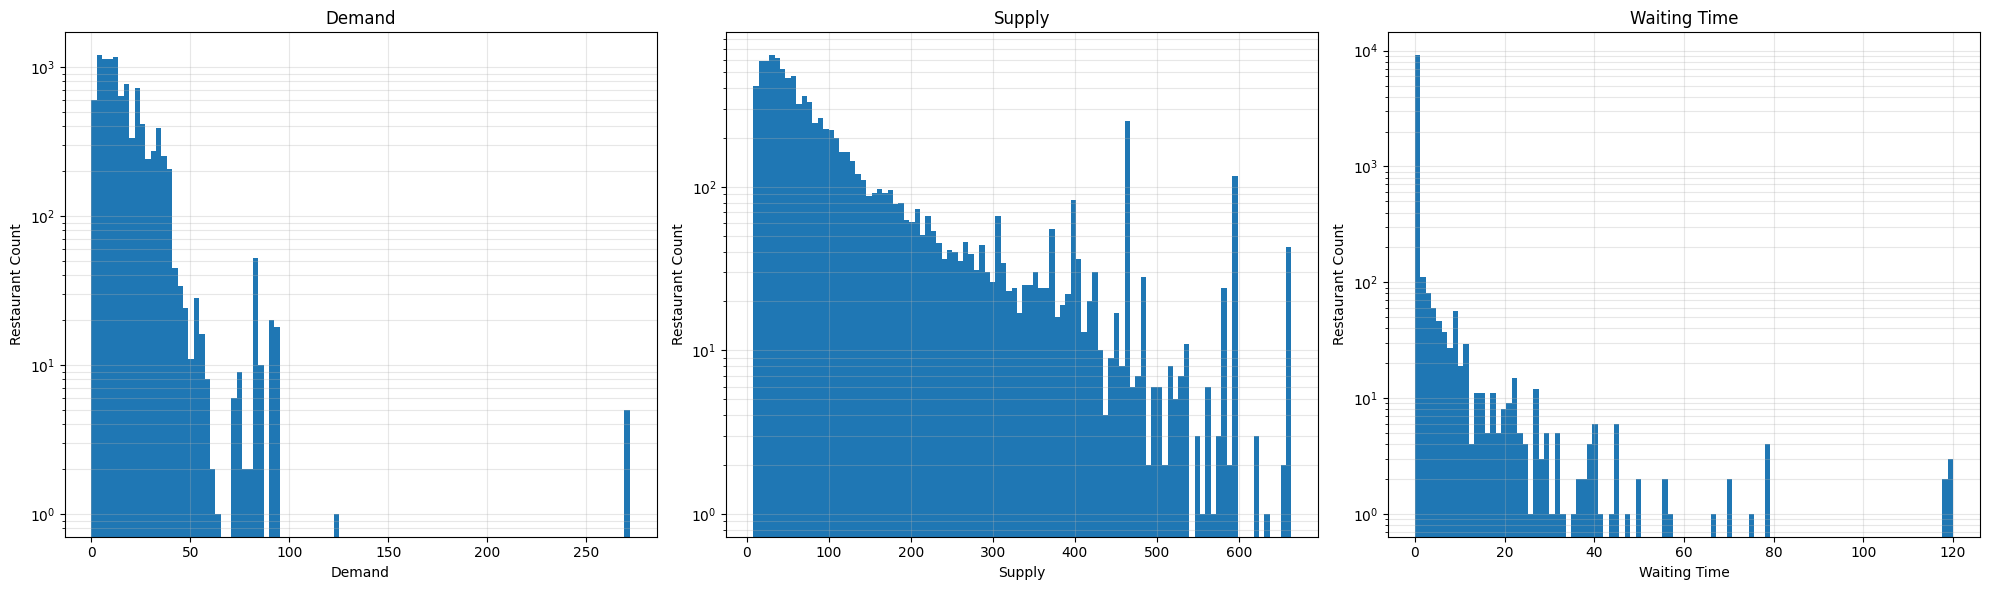

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

df = pd.read_csv("restaurant_wait_now.csv")

# ------------------------
# Variables
# ------------------------

demand = pd.to_numeric(
    df["effective_demand"],
    errors="coerce"
).dropna()

supply = pd.to_numeric(
    df["effective_supply_index"],
    errors="coerce"
).dropna()

wait = pd.to_numeric(
    df["estimated_wait_minutes"],
    errors="coerce"
).dropna()

# ------------------------
# Plot
# ------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20,6)
)

plots = [
    ("Demand", demand),
    ("Supply", supply),
    ("Waiting Time", wait)
]

for ax, (title, series) in zip(axes, plots):

    ax.hist(
        series,
        bins=100
    )

    # only y-axis log scale
    ax.set_yscale("log")

    ax.yaxis.set_major_locator(
        LogLocator(base=10)
    )

    ax.set_title(title)

    ax.set_xlabel(title)
    ax.set_ylabel("Restaurant Count")

    ax.grid(
        alpha=0.3,
        which="both"
    )

plt.tight_layout()
plt.show()

In [24]:
for name, series in plots:

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print(series.describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    ))


Demand
count    9754.000000
mean       16.592470
std        14.567450
min         0.034171
25%         6.395845
50%        13.082725
75%        23.206225
90%        34.158436
95%        38.399062
99%        82.106578
max       272.060808
Name: effective_demand, dtype: float64

Supply
count    9754.000000
mean      125.840604
std       136.505142
min         7.600000
25%        36.174600
50%        71.280000
75%       155.695290
90%       345.438306
95%       460.800000
99%       597.600000
max       664.000000
Name: effective_supply_index, dtype: float64

Waiting Time
count    9754.000000
mean        0.763987
std         4.926502
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
90%         0.018779
95%         2.705588
99%        20.760165
max       120.000000
Name: estimated_wait_minutes, dtype: float64


In [25]:
df["utilization"] = (
    df["effective_demand"]
    /
    df["effective_supply_index"]
)
df["utilization"].describe(
    percentiles=[
        .25,
        .5,
        .75,
        .9,
        .95,
        .99
    ]
)

count    9754.000000
mean        0.332694
std         0.490409
min         0.000079
25%         0.065570
50%         0.159399
75%         0.400381
90%         0.815220
95%         1.218318
99%         2.427373
max         8.051042
Name: utilization, dtype: float64

# Sitimuation of Users and Orders

In [27]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================
# 1. Config
# =========================
np.random.seed(42)

N_USERS = 1000
START_DATE = "2026-03-01"
END_DATE = "2026-05-31"

restaurants = pd.read_csv("restaurant_wait_now.csv")

# keep usable restaurants
restaurants = restaurants.dropna(subset=["restaurant_id", "name", "cuisine"])
restaurants["restaurant_id"] = restaurants["restaurant_id"].astype(int)

# =========================
# 2. Generate users
# =========================

def sample_age_group(n):
    # Approximate adult-oriented NYC age distribution for app users
    age_groups = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
    probs = [0.13, 0.28, 0.22, 0.16, 0.12, 0.09]
    return np.random.choice(age_groups, size=n, p=probs)

def sample_age_from_group(group):
    ranges = {
        "18-24": (18, 24),
        "25-34": (25, 34),
        "35-44": (35, 44),
        "45-54": (45, 54),
        "55-64": (55, 64),
        "65+": (65, 85),
    }
    low, high = ranges[group]
    return np.random.randint(low, high + 1)

top_cuisines = restaurants["cuisine"].value_counts().head(20).index.tolist()

age_groups = sample_age_group(N_USERS)

users = pd.DataFrame({
    "user_id": range(1, N_USERS + 1),
    "age_group": age_groups,
    "age": [sample_age_from_group(g) for g in age_groups],
    "gender": np.random.choice(
        ["female", "male"],
        size=N_USERS,
        p=[0.525, 0.475]
    ),
    "budget_tier": np.random.choice(
        ["low", "medium", "high"],
        size=N_USERS,
        p=[0.35, 0.45, 0.20]
    ),
    "preferred_cuisine_1": np.random.choice(top_cuisines, size=N_USERS),
    "preferred_cuisine_2": np.random.choice(top_cuisines, size=N_USERS),
    "dietary_restriction": np.random.choice(
        ["none", "vegetarian", "halal", "kosher", "gluten_free"],
        size=N_USERS,
        p=[0.75, 0.10, 0.06, 0.05, 0.04]
    ),
    "signup_date": pd.to_datetime(START_DATE) - pd.to_timedelta(
        np.random.randint(0, 180, size=N_USERS), unit="D"
    ),
    "acquisition_channel": np.random.choice(
        ["organic", "paid_search", "social_media", "referral", "restaurant_qr"],
        size=N_USERS,
        p=[0.35, 0.20, 0.20, 0.15, 0.10]
    )
})

# avoid same cuisine preference twice where possible
same_pref = users["preferred_cuisine_1"] == users["preferred_cuisine_2"]
users.loc[same_pref, "preferred_cuisine_2"] = np.random.choice(top_cuisines, same_pref.sum())

# =========================
# 3. Generate order counts
# =========================
# Negative binomial creates right-skewed long-tail counts.
# Then clip to 0-20.
raw_counts = np.random.negative_binomial(n=2, p=2 / 7, size=N_USERS)
order_counts = np.clip(raw_counts, 0, 20)

# adjust roughly toward mean 5
while order_counts.mean() < 4.7:
    idx = np.random.choice(N_USERS)
    order_counts[idx] = min(order_counts[idx] + 1, 20)

while order_counts.mean() > 5.3:
    idx = np.random.choice(np.where(order_counts > 0)[0])
    order_counts[idx] -= 1

users["simulated_order_count"] = order_counts

print("Mean orders per user:", users["simulated_order_count"].mean())
print(users["simulated_order_count"].describe())

# =========================
# 4. Generate orders
# =========================

date_range = pd.date_range(START_DATE, END_DATE, freq="D")

def random_order_datetime():
    day = np.random.choice(date_range)

    # restaurant demand peak: lunch + dinner
    hour = np.random.choice(
        list(range(8, 23)),
        p=np.array([
            0.03, 0.04, 0.05, 0.07, 0.10,
            0.09, 0.06, 0.05, 0.05, 0.07,
            0.10, 0.12, 0.10, 0.05, 0.02
        ])
    )

    minute = np.random.randint(0, 60)
    second = np.random.randint(0, 60)

    return pd.Timestamp(day).replace(hour=hour, minute=minute, second=second)

def choose_restaurant_for_user(user):
    # 70% chance choose preferred cuisine, 30% explore other cuisines
    if np.random.rand() < 0.7:
        cuisine = np.random.choice([user["preferred_cuisine_1"], user["preferred_cuisine_2"]])
        pool = restaurants[restaurants["cuisine"] == cuisine]
        if len(pool) == 0:
            pool = restaurants
    else:
        pool = restaurants

    return pool.sample(1).iloc[0]

orders = []
order_id = 1

for _, user in users.iterrows():
    for _ in range(int(user["simulated_order_count"])):
        r = choose_restaurant_for_user(user)

        order_time = random_order_datetime()
        reservation_time = order_time + pd.to_timedelta(
            np.random.choice([15, 30, 45, 60, 90, 120], p=[0.15, 0.25, 0.25, 0.18, 0.12, 0.05]),
            unit="m"
        )

        estimated_wait = float(r.get("estimated_wait_minutes", 0))
        if np.isnan(estimated_wait):
            estimated_wait = 0

        actual_wait = max(
            0,
            np.random.normal(
                loc=estimated_wait,
                scale=max(3, estimated_wait * 0.35)
            )
        )

        discount_used = np.random.rand() < 0.22

        base_amount = {
            "low": 18,
            "medium": 35,
            "high": 65
        }[user["budget_tier"]]

        party_size = np.random.choice([1, 2, 3, 4, 5, 6], p=[0.20, 0.45, 0.15, 0.13, 0.05, 0.02])

        total_amount = np.random.gamma(shape=2.2, scale=base_amount / 2.2) * party_size
        discount_amount = total_amount * np.random.choice([0.10, 0.15, 0.20, 0.25]) if discount_used else 0

        status = np.random.choice(
            ["completed", "cancelled", "no_show"],
            p=[0.86, 0.10, 0.04]
        )

        orders.append({
            "order_id": order_id,
            "user_id": int(user["user_id"]),
            "restaurant_id": int(r["restaurant_id"]),
            "order_time": order_time,
            "reservation_time": reservation_time,
            "party_size": int(party_size),
            "cuisine": r["cuisine"],
            "estimated_travel_minutes": round(np.random.uniform(5, 45), 1),
            "estimated_wait_minutes": round(estimated_wait, 1),
            "actual_wait_minutes": round(actual_wait, 1),
            "order_status": status,
            "total_amount": round(total_amount, 2),
            "discount_used": discount_used,
            "discount_amount": round(discount_amount, 2),
            "created_at": order_time
        })

        order_id += 1

orders = pd.DataFrame(orders)

# =========================
# 5. Export
# =========================
users.to_csv("sim_users.csv", index=False)
orders.to_csv("sim_orders.csv", index=False)

print("Users:", users.shape)
print("Orders:", orders.shape)
print("Order date range:", orders["order_time"].min(), "to", orders["order_time"].max())
print("Mean orders per user:", len(orders) / len(users))

display(users.head())
display(orders.head())

Mean orders per user: 4.946
count    1000.00000
mean        4.94600
std         3.97201
min         0.00000
25%         2.00000
50%         4.00000
75%         7.00000
max        20.00000
Name: simulated_order_count, dtype: float64
Users: (1000, 11)
Orders: (4946, 15)
Order date range: 2026-03-01 09:06:21 to 2026-05-31 21:54:05
Mean orders per user: 4.946


,user_id,age_group,age,gender,budget_tier,preferred_cuisine_1,preferred_cuisine_2,dietary_restriction,signup_date,acquisition_channel,simulated_order_count
0,1,25-34,32,female,low,Thai,French,none,2026-01-07,paid_search,2
1,2,65+,83,female,low,Pizza,Latin American,vegetarian,2025-10-20,organic,10
2,3,45-54,52,male,medium,Korean,Japanese,none,2025-10-12,restaurant_qr,0
3,4,35-44,39,female,low,Asian/Asian Fusion,Latin American,none,2025-09-27,paid_search,4
4,5,25-34,25,male,medium,Thai,Sandwiches,none,2026-01-18,organic,3


,order_id,user_id,restaurant_id,order_time,reservation_time,party_size,cuisine,estimated_travel_minutes,estimated_wait_minutes,actual_wait_minutes,order_status,total_amount,discount_used,discount_amount,created_at
0,1,1,50165007,2026-05-03 11:22:46,2026-05-03 12:07:46,4,American,42.9,0.0,2.1,completed,271.14,False,0.0,2026-05-03 11:22:46
1,2,1,40384671,2026-03-25 12:23:39,2026-03-25 12:53:39,2,French,25.4,0.0,4.3,cancelled,16.44,False,0.0,2026-03-25 12:23:39
2,3,2,50137589,2026-03-11 18:53:59,2026-03-11 19:53:59,2,Italian,31.0,0.0,0.4,completed,19.51,False,0.0,2026-03-11 18:53:59
3,4,2,50128782,2026-05-30 12:33:44,2026-05-30 13:33:44,3,Latin American,40.3,0.0,0.0,completed,136.81,False,0.0,2026-05-30 12:33:44
4,5,2,50136413,2026-03-28 19:16:38,2026-03-28 19:46:38,1,Pizza,42.4,0.0,2.4,completed,25.99,False,0.0,2026-03-28 19:16:38


# Situmuation of Promotion

In [31]:
# =========================
# 6. Generate promotions
# =========================

N_PROMOTIONS = 20

promotion_restaurants = restaurants.sample(N_PROMOTIONS, random_state=42)

promotions = []

for i, (_, r) in enumerate(promotion_restaurants.iterrows(), start=1):
    start_time = pd.Timestamp(START_DATE) + pd.to_timedelta(
        np.random.randint(0, 75), unit="D"
    )
    duration_days = np.random.choice([3, 5, 7, 10, 14], p=[0.15, 0.25, 0.30, 0.20, 0.10])
    end_time = min(start_time + pd.to_timedelta(duration_days, unit="D"), pd.Timestamp(END_DATE))

    discount_type = np.random.choice(["percentage", "fixed"], p=[0.7, 0.3])

    if discount_type == "percentage":
        discount_value = np.random.choice([0.10, 0.15, 0.20, 0.25])
    else:
        discount_value = np.random.choice([5, 8, 10, 12])

    promotions.append({
        "promotion_id": i,
        "restaurant_id": int(r["restaurant_id"]),
        "cuisine": r["cuisine"],
        "promotion_name": f"{r['cuisine']} Promo {i}",
        "discount_type": discount_type,
        "discount_value": discount_value,
        "start_time": start_time,
        "end_time": end_time,
        "target_segment": np.random.choice(
            ["all_users", "new_users", "active_users", "dormant_users"],
            p=[0.35, 0.20, 0.25, 0.20]
        ),
        "created_at": start_time - pd.to_timedelta(np.random.randint(1, 7), unit="D")
    })

promotions = pd.DataFrame(promotions)

# =========================
# 7. Generate promotion exposures
# =========================

def get_user_segment(user_id, promo_start):
    user_orders = orders[
        (orders["user_id"] == user_id) &
        (orders["order_status"] == "completed") &
        (orders["order_time"] < promo_start)
    ]

    if len(user_orders) == 0:
        return "new_users"

    last_order_time = user_orders["order_time"].max()
    days_since_last_order = (promo_start - last_order_time).days

    if days_since_last_order >= 30:
        return "dormant_users"
    else:
        return "active_users"


exposures = []
exposure_id = 1

for _, promo in promotions.iterrows():
    promo_start = pd.Timestamp(promo["start_time"])
    promo_end = pd.Timestamp(promo["end_time"])
    target_segment = promo["target_segment"]

    candidate_users = []

    for _, user in users.iterrows():
        segment = get_user_segment(user["user_id"], promo_start)

        if target_segment == "all_users" or target_segment == segment:
            candidate_users.append(user["user_id"])

    # exposure size
    if len(candidate_users) == 0:
        continue

    exposure_rate = {
        "all_users": 0.45,
        "new_users": 0.60,
        "active_users": 0.50,
        "dormant_users": 0.70
    }[target_segment]

    exposed_users = np.random.choice(
        candidate_users,
        size=max(1, int(len(candidate_users) * exposure_rate)),
        replace=False
    )

    for user_id in exposed_users:
        exposed_at = promo_start + pd.to_timedelta(
            np.random.randint(0, max(1, (promo_end - promo_start).days + 1)),
            unit="D"
        ) + pd.to_timedelta(np.random.randint(9, 21), unit="h")

        user_row = users.loc[users["user_id"] == user_id].iloc[0]

        clicked = np.random.rand() < {
            "all_users": 0.18,
            "new_users": 0.22,
            "active_users": 0.25,
            "dormant_users": 0.15
        }[target_segment]

        clicked_at = None
        if clicked:
            clicked_at = exposed_at + pd.to_timedelta(np.random.randint(1, 180), unit="m")

        # check whether this user placed an order at the promoted restaurant after exposure
        user_after_orders = orders[
            (orders["user_id"] == user_id) &
            (orders["restaurant_id"] == promo["restaurant_id"]) &
            (orders["order_time"] >= exposed_at) &
            (orders["order_time"] <= promo_end + pd.to_timedelta(7, unit="D")) &
            (orders["order_status"] == "completed")
        ]

        redeemed = clicked and (np.random.rand() < 0.35)

        if redeemed and len(user_after_orders) > 0:
            redeemed_order_id = int(user_after_orders.sample(1)["order_id"].iloc[0])
        else:
            redeemed_order_id = None

        exposures.append({
            "exposure_id": exposure_id,
            "promotion_id": int(promo["promotion_id"]),
            "user_id": int(user_id),
            "restaurant_id": int(promo["restaurant_id"]),
            "target_segment": target_segment,
            "exposed_at": exposed_at,
            "channel": np.random.choice(
                ["push", "email", "in_app"],
                p=[0.55, 0.25, 0.20]
            ),
            "clicked": clicked,
            "clicked_at": clicked_at,
            "redeemed": redeemed_order_id is not None,
            "redeemed_order_id": redeemed_order_id
        })

        exposure_id += 1

promotion_exposures = pd.DataFrame(exposures)

# =========================
# 8. Export
# =========================

promotions.to_csv("sim_promotions.csv", index=False)
promotion_exposures.to_csv("sim_promotion_exposures.csv", index=False)

print("Promotions:", promotions.shape)
print("Promotion exposures:", promotion_exposures.shape)

display(promotions.head())
display(promotion_exposures.head())

Promotions: (20, 10)
Promotion exposures: (6552, 11)


,promotion_id,restaurant_id,cuisine,promotion_name,discount_type,discount_value,start_time,end_time,target_segment,created_at
0,1,50150310,Coffee/Tea,Coffee/Tea Promo 1,percentage,0.25,2026-05-05,2026-05-12,dormant_users,2026-05-04
1,2,50001835,American,American Promo 2,fixed,12.00,2026-03-14,2026-03-17,all_users,2026-03-10
2,3,50150010,Coffee/Tea,Coffee/Tea Promo 3,percentage,0.15,2026-03-23,2026-04-02,dormant_users,2026-03-20
3,4,50135792,Korean,Korean Promo 4,percentage,0.25,2026-04-21,2026-04-24,all_users,2026-04-18
4,5,50146135,Chinese,Chinese Promo 5,percentage,0.25,2026-04-29,2026-05-04,all_users,2026-04-28


,exposure_id,promotion_id,user_id,restaurant_id,target_segment,exposed_at,channel,clicked,clicked_at,redeemed,redeemed_order_id
0,1,1,702,50150310,dormant_users,2026-05-12 14:00:00,email,False,NaT,False,None
1,2,1,374,50150310,dormant_users,2026-05-12 19:00:00,push,True,2026-05-12 19:45:00,False,None
2,3,1,904,50150310,dormant_users,2026-05-12 20:00:00,push,False,NaT,False,None
3,4,1,156,50150310,dormant_users,2026-05-07 15:00:00,in_app,False,NaT,False,None
4,5,1,759,50150310,dormant_users,2026-05-09 14:00:00,push,False,NaT,False,None
